#### ANÁLISE DO DATASET:

##### IMDB movies dataset
Link:
https://www.kaggle.com/datasets/ashpalsingh1525/imdb-movies-dataset?resource=download

O cliente quer entender dois pontos antes de decidir onde investir:
1. o que faz um filme ser bem aceito pelo público;
2. o que faz um filme gerar retorno financeiro;
e, principalmente, onde essas duas dimensões não caminham juntas.
A análise não pretende provar causalidade. Correlação e diferenças entre grupos serão usadas como evidências para levantar hipóteses de negócio.

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ARQUIVO = "imdb_movies.csv"

df = pd.read_csv(ARQUIVO)



print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
display(df.head())


Linhas: 10,178
Colunas: 12


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.00,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,"75,000,000.00","271,616,668.00",AU
1,Avatar: The Way of Water,12/15/2022,78.00,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,"460,000,000.00","2,316,794,914.00",AU
2,The Super Mario Bros. Movie,04/05/2023,76.00,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,"100,000,000.00","724,459,031.00",AU
3,Mummies,01/05/2023,70.00,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian","12,300,000.00","34,200,000.00",AU
4,Supercell,03/17/2023,61.00,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,"77,000,000.00","340,941,958.60",US


In [10]:
df.columns = df.columns.str.strip()
print(columns := df.columns.tolist())

['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title', 'status', 'orig_lang', 'budget_x', 'revenue', 'country']


In [11]:

# Padronização básica
df.columns = df.columns.str.strip()

for col in ["score", "budget_x", "revenue"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["names", "genre", "crew", "orig_title", "status", "orig_lang", "country"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Datas
df["date"] = pd.to_datetime(df["date_x"].astype("string").str.strip(),
                            errors="coerce", format="%m/%d/%Y")
df["year"] = df["date"].dt.year

# Variáveis derivadas
df["log_budget"] = np.log10(df["budget_x"].where(df["budget_x"] > 0))
df["log_revenue"] = np.log10(df["revenue"].where(df["revenue"] > 0))

print("Tipos:")
display(df.dtypes)


Tipos:


names                  string
date_x                    str
score                 float64
genre                  string
overview                  str
crew                   string
orig_title             string
status                 string
orig_lang              string
budget_x              float64
revenue               float64
country                string
date           datetime64[us]
year                    int32
log_budget            float64
log_revenue           float64
dtype: object

#### 1. Além do gênero, o que mais parece influenciar a nota que um filme recebe do público?

In [12]:

# Correlação entre as principais variáveis numéricas e a nota
correlacoes = (
    df[["score", "budget_x", "revenue", "year"]]
    .corr(numeric_only=True)["score"]
    .drop("score")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(correlacoes.to_frame("correlacao_com_nota"))

# Número de filmes por faixa de nota
df["faixa_nota"] = pd.cut(
    df["score"],
    bins=[-np.inf, 59.99, 69.99, 79.99, np.inf],
    labels=["< 60", "60–69", "70–79", "≥ 80"]
)

display(df["faixa_nota"].value_counts().sort_index())


,correlacao_com_nota
budget_x,-0.24
year,-0.15
revenue,0.10


faixa_nota
< 60     2699
60–69    4184
70–79    2864
≥ 80      431
Name: count, dtype: int64

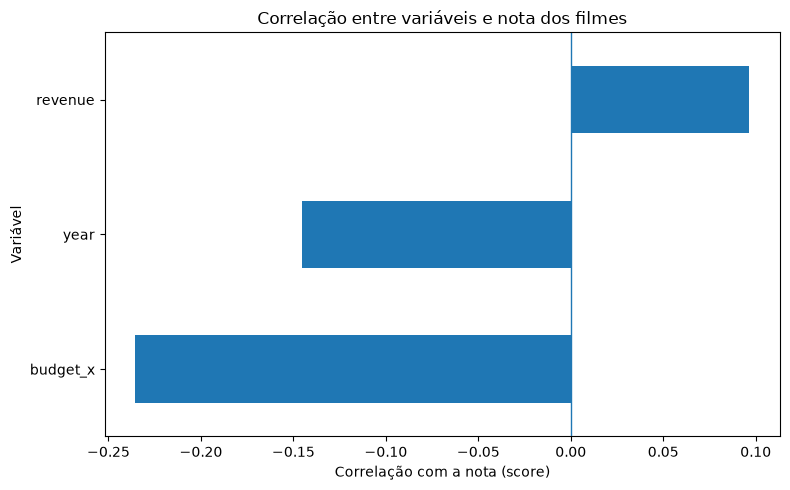

In [13]:
import matplotlib.pyplot as plt

# Gráfico da correlação das variáveis com a nota
plt.figure(figsize=(8, 5))

correlacoes.sort_values().plot(
    kind="barh"
)

plt.axvline(0, linewidth=1)
plt.title("Correlação entre variáveis e nota dos filmes")
plt.xlabel("Correlação com a nota (score)")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

,media,mediana,filmes
genre,,,
History,69.16,71.00,422
War,69.07,70.00,282
Animation,68.99,70.00,1468
Music,68.71,70.00,277
Western,68.01,68.00,131
Family,66.21,67.00,1407
Drama,65.95,68.00,3812
Fantasy,65.72,67.00,1382
Adventure,65.27,66.00,1890


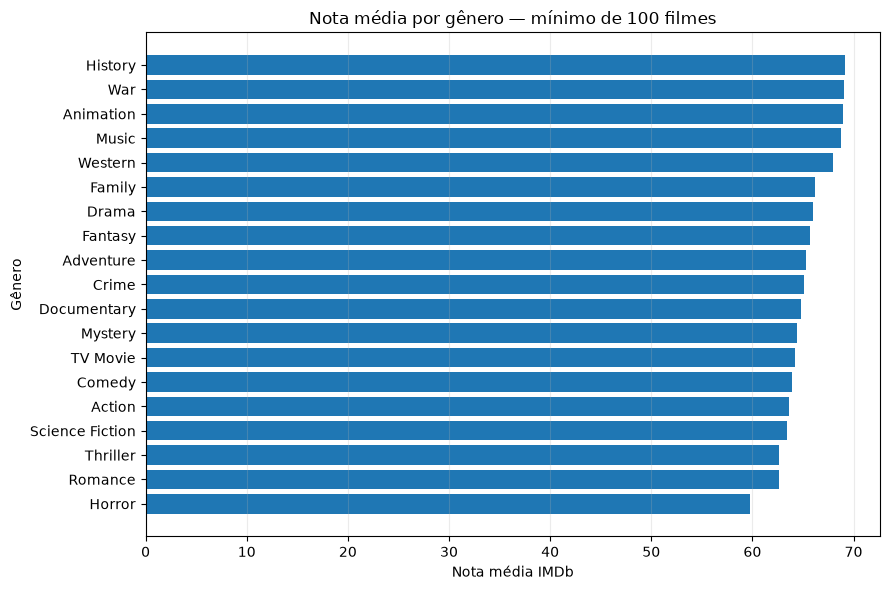

In [14]:

# Gênero: separar os gêneros que estão juntos em uma mesma célula
generos = (
    df[["genre", "score"]]
    .dropna(subset=["genre", "score"])
    .assign(genre=lambda x: x["genre"].str.split(r",\s*"))
    .explode("genre")
)

generos["genre"] = generos["genre"].str.replace("\xa0", " ", regex=False).str.strip()

resumo_genero = (
    generos.groupby("genre")["score"]
    .agg(media="mean", mediana="median", filmes="count")
    .query("filmes >= 100")
    .sort_values("media", ascending=False)
)

display(resumo_genero)

# Gráfico principal
graf_genero = resumo_genero.sort_values("media")

plt.figure(figsize=(9, 6))
plt.barh(graf_genero.index, graf_genero["media"])
plt.xlabel("Nota média IMDb")
plt.ylabel("Gênero")
plt.title("Nota média por gênero — mínimo de 100 filmes")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


#### Conclusão — Pergunta 1

Além do gênero, as variáveis financeiras não mostram uma relação positiva forte com a nota. O orçamento apresenta correlação negativa com a avaliação, enquanto a receita apresenta relação linear muito fraca.

Isso sugere que **investir mais dinheiro não garante maior aceitação do público**. O gênero apresenta diferenças nas médias, mas também não deve ser interpretado como causa isolada do sucesso.

**Insight de negócio:** para aumentar a chance de aceitação, não é suficiente simplesmente aumentar o orçamento. Seria necessário investigar características de conteúdo, equipe criativa, direção, roteiro, franquia e posicionamento do filme — informações que o dataset atual não estrutura adequadamente.


#### 2. Existe alguma coisa que esperávamos encontrar e não encontramos?

In [15]:
# Inventário das colunas disponíveis
inventario = pd.DataFrame({
    "coluna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "percentual_nulos": (df.isna().mean() * 100).round(2).values
})

display(inventario)

,coluna,tipo,nulos,percentual_nulos
0,names,string,0,0.00
1,date_x,str,0,0.00
2,score,float64,0,0.00
3,genre,string,85,0.84
4,overview,str,0,0.00
5,crew,string,56,0.55
6,orig_title,string,0,0.00
7,status,string,0,0.00
8,orig_lang,string,0,0.00
9,budget_x,float64,0,0.00


#### Conclusão — Pergunta 2

O dataset possui título, data, nota, gênero, sinopse, `crew`, idioma, orçamento, receita e país. Porém, faltam informações estruturadas importantes para uma decisão de investimento:

- diretor;
- produtor;
- roteirista;
- estúdio/distribuidora;
- franquia/série;
- investimento em marketing;
- número de salas/alcance de distribuição;
- nota de críticos;
- bilheteria de abertura.

Se essas informações fossem necessárias, o próximo passo seria **enriquecer o dataset com outras fontes**, criando uma base integrada antes de tirar conclusões financeiras ou sobre profissionais.

#### 3. Filmes muito bem avaliados pelo público costumam ter algo em comum?

In [16]:

# Definindo "muito bem avaliados" como nota >= 80
muito_bem_avaliados = df[df["score"] >= 80].copy()
demais_filmes = df[df["score"] < 80].copy()

comparacao = pd.DataFrame({
    "grupo": ["Nota >= 80", "Nota < 80"],
    "quantidade": [len(muito_bem_avaliados), len(demais_filmes)],
    "orcamento_mediano": [
        muito_bem_avaliados["budget_x"].median(),
        demais_filmes["budget_x"].median()
    ],
    "receita_mediana": [
        muito_bem_avaliados["revenue"].median(),
        demais_filmes["revenue"].median()
    ],
    "nota_media": [
        muito_bem_avaliados["score"].mean(),
        demais_filmes["score"].mean()
    ]
})

display(comparacao)
print(f"Percentual de filmes com nota >= 80: {len(muito_bem_avaliados)/len(df)*100:.2f}%")


,grupo,quantidade,orcamento_mediano,receita_mediana,nota_media
0,Nota >= 80,431,"35,000,000.00","230,098,753.00",82.44
1,Nota < 80,9747,"50,000,000.00","152,022,333.00",62.66


Percentual de filmes com nota >= 80: 4.23%



#### Conclusão — Pergunta 3

Os filmes muito bem avaliados representam uma parcela pequena do dataset. Um ponto relevante é que eles **não apresentam orçamento mediano maior** que os demais filmes.

Isso reforça a hipótese de que qualidade percebida não depende apenas de recursos financeiros. O padrão de sucesso provavelmente envolve uma combinação de fatores criativos e de produção que não estão totalmente disponíveis no dataset.

**Importante:** o resultado indica associação, não prova quais fatores causam uma nota alta.


#### 4. A informação sobre quem trabalhou em cada filme é suficiente?

In [17]:

# Inspeção de alguns registros da coluna crew
display(df[["names", "crew"]].head(10))

# Quantidade média de itens listados em crew
df["crew_qtd_itens"] = (
    df["crew"]
    .fillna("")
    .apply(lambda x: len([item for item in x.split(",") if item.strip()]))
)

display(df["crew_qtd_itens"].describe())


,names,crew
0,Creed III,"Michael B. Jordan, Adonis Creed, Tessa Thompso..."
1,Avatar: The Way of Water,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt..."
2,The Super Mario Bros. Movie,"Chris Pratt, Mario (voice), Anya Taylor-Joy, P..."
3,Mummies,"Óscar Barberán, Thut (voice), Ana Esther Albor..."
4,Supercell,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin..."
5,Cocaine Bear,"Keri Russell, Sari, Alden Ehrenreich, Eddie, O..."
6,John Wick: Chapter 4,"Keanu Reeves, John Wick, Donnie Yen, Caine, Bi..."
7,Puss in Boots: The Last Wish,"Antonio Banderas, Puss in Boots (voice), Salma..."
8,Attack on Titan,"Paul Bianchi, Computer (voice), Erin Coker, Al..."
9,The Park,"Chloe Guidry, Ines, Nhedrick Jabier, Bui, Carm..."


count   10,178.00
mean        16.86
std          3.40
min          0.00
25%         18.00
50%         18.00
75%         18.00
max         24.00
Name: crew_qtd_itens, dtype: float64


#### Conclusão — Pergunta 4

**Não.**

A coluna `crew` não apresenta uma estrutura que permita separar claramente diretor, produtor, roteirista e demais funções. Nos registros observados, aparecem nomes de pessoas associados a personagens, o que impede uma análise confiável sobre quem efetivamente construiu cada filme.

Portanto, essa variável pode ser explorada descritivamente, mas **não é suficiente para explicar o desempenho dos profissionais por trás dos filmes**.


#### 5. Como descobrir um padrão de sucesso ligado às pessoas por trás dos filmes?


#### Estratégia analítica proposta

Para responder corretamente a essa pergunta, eu faria um enriquecimento da base com:

`diretor`, `produtor`, `roteirista`, `estúdio` e `franquia`.

Depois, para cada profissional, calcularia:

- quantidade de filmes;
- nota média e mediana;
- percentual de filmes com nota ≥ 80;
- receita média e mediana;
- desempenho por gênero;
- desempenho por faixa de orçamento.

O ponto importante é **controlar o contexto**. Um diretor pode apresentar receita alta simplesmente porque trabalha com grandes franquias. Portanto, não basta comparar médias brutas.

A análise ideal seria uma combinação de agrupamentos, visualizações e, posteriormente, um modelo estatístico que controle gênero, orçamento, ano e franquia.


In [18]:

# Diagnóstico da coluna crew:
# mostra os termos mais frequentes, sem tratá-los como "diretores".
from collections import Counter

nomes_crew = []
for valor in df["crew"].dropna():
    nomes_crew.extend([x.strip() for x in valor.split(",") if x.strip()])

frequencias_crew = (
    pd.Series(nomes_crew)
    .value_counts()
    .head(20)
    .rename("ocorrencias")
)

display(frequencias_crew.to_frame())


,ocorrencias
Self,807
Himself,184
Jack,89
Bruce Willis,85
Paul,80
Sam,77
David,77
Peter,75
Sarah,75
Frank,74


#### 6. Os filmes que mais faturaram são também os mais bem avaliados? Sempre?

In [19]:

# Top 15 filmes por receita
top_receita = (
    df[["names", "score", "budget_x", "revenue"]]
    .dropna(subset=["revenue"])
    .sort_values("revenue", ascending=False)
    .head(15)
)

display(top_receita)

# Percentual dos 10% maiores faturamentos que têm nota abaixo de 70
limite_top10 = df["revenue"].quantile(0.90)
top10_receita = df[df["revenue"] >= limite_top10].dropna(subset=["score"])

percentual_baixa_nota = (top10_receita["score"] < 70).mean() * 100

print(f"Limite dos 10% maiores faturamentos: {limite_top10:,.0f}")
print(f"Nos 10% maiores faturamentos, {percentual_baixa_nota:.1f}% têm nota abaixo de 70.")


,names,score,budget_x,revenue
68,Avatar,76.00,"237,000,000.00","2,923,706,026.00"
230,Avengers: Endgame,83.00,"400,000,000.00","2,794,731,755.00"
1,Avatar: The Way of Water,78.00,"460,000,000.00","2,316,794,914.00"
309,Titanic,79.00,"200,000,000.00","2,222,985,568.00"
6670,Titanic,66.00,"200,000,000.00","2,222,985,568.00"
4483,Louis Tomlinson: All of Those Voices,91.00,"178,800,000.00","2,081,794,005.60"
943,Star Wars: The Force Awakens,73.00,"245,000,000.00","2,068,223,624.00"
104,Avengers: Infinity War,83.00,"300,000,000.00","2,048,359,754.00"
5683,Rathinirvedam,95.00,"227,800,000.00","1,916,346,674.60"
76,Spider-Man: No Way Home,80.00,"200,000,000.00","1,910,048,245.00"


Limite dos 10% maiores faturamentos: 642,595,903
Nos 10% maiores faturamentos, 47.9% têm nota abaixo de 70.


,names,score,budget_x,revenue
8232,Housekeeper,100.00,"201,000,000.00","1,569,323,843.80"
6433,"Furin, hentai, monmon chômon",100.00,"201,000,000.00","1,569,323,843.80"
1776,Porno document: Toruko tokkyû bin,100.00,"201,000,000.00","1,569,323,843.80"
443,El asistente,100.00,"201,000,000.00","1,569,323,843.80"
5404,The Chosen: Season 3 - Episodes 1 & 2,100.00,"201,000,000.00","1,569,323,843.80"
277,Orgasm Lecture 2,100.00,"201,000,000.00","1,569,323,843.80"
10046,Simulant,100.00,"201,000,000.00","1,569,323,843.80"
934,Female Boss Hooker,100.00,"201,000,000.00","1,569,323,843.80"
4887,Pretty Young Sister 4,100.00,"201,000,000.00","1,569,323,843.80"
7815,Rebound,98.00,"45,000,000.00","17,492,014.00"


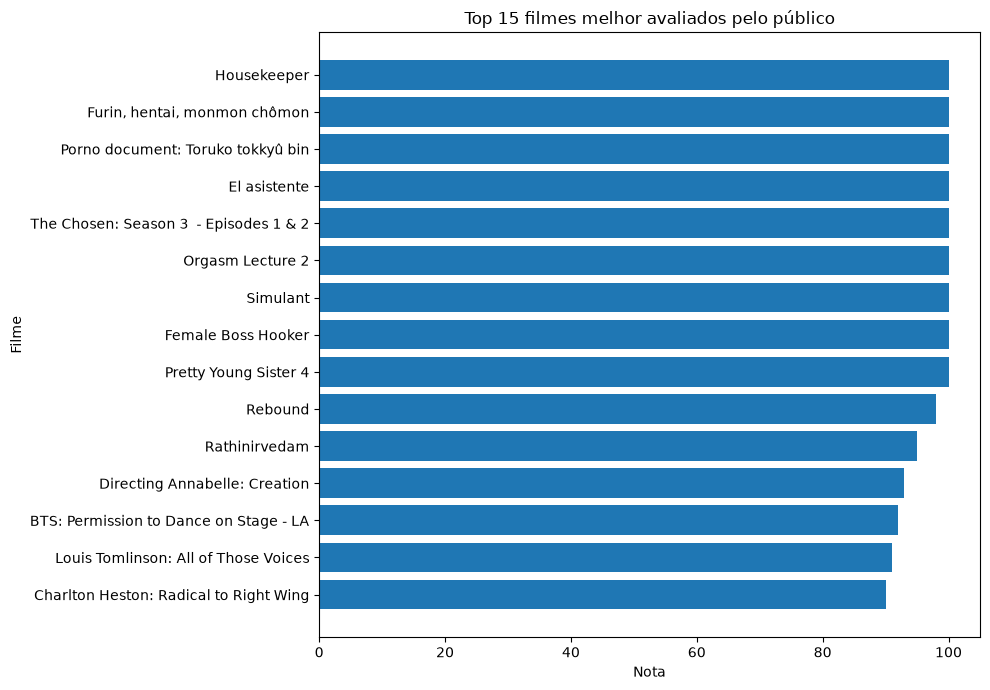

In [20]:
# Top 15 filmes melhor avaliados pelo público
top_avaliados = (
    df[["names", "score", "budget_x", "revenue"]]
    .dropna(subset=["score"])
    .sort_values("score", ascending=False)
    .head(15)
)

display(top_avaliados)

# Gráfico
plt.figure(figsize=(10, 7))

plt.barh(
    top_avaliados["names"],
    top_avaliados["score"]
)

plt.xlabel("Nota")
plt.ylabel("Filme")
plt.title("Top 15 filmes melhor avaliados pelo público")

# Coloca o filme com maior nota no topo
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

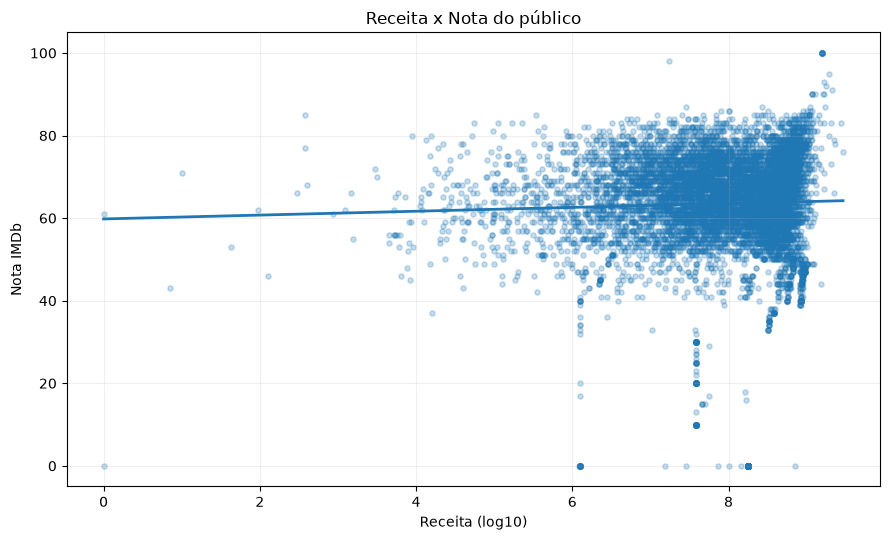

In [21]:

# Gráfico principal: receita x nota
dados_graf = df[["log_revenue", "score"]].dropna()

plt.figure(figsize=(9, 5.5))
plt.scatter(dados_graf["log_revenue"], dados_graf["score"], alpha=0.25, s=14)

coef = np.polyfit(dados_graf["log_revenue"], dados_graf["score"], 1)
x = np.linspace(dados_graf["log_revenue"].min(), dados_graf["log_revenue"].max(), 100)
plt.plot(x, np.polyval(coef, x), linewidth=2)

plt.xlabel("Receita (log10)")
plt.ylabel("Nota IMDb")
plt.title("Receita x Nota do público")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


#### Conclusão — Pergunta 6

**Não.**

Os maiores faturamentos não correspondem necessariamente às maiores notas. A relação linear entre receita e nota é fraca.

Isso é central para a decisão de negócio: **sucesso financeiro e aceitação do público devem ser tratados como KPIs diferentes**.

Um filme pode gerar muito dinheiro mesmo apresentando avaliação apenas mediana.


#### 7. O que pode explicar um filme que fatura muito, mas recebe nota mediana ou baixa?


O dataset permite levantar hipóteses, mas não permite provar todas elas.

Possíveis explicações a investigar:

1. **Franquia conhecida:** o público já possui interesse antes do lançamento.
2. **Marketing:** campanhas grandes podem gerar demanda inicial.
3. **Distribuição:** lançamento em muitos mercados e salas amplia o potencial de receita.
4. **Personagens/universos conhecidos:** reduzem a necessidade de criar demanda do zero.
5. **Sequências:** um filme pode se beneficiar da audiência construída por títulos anteriores.
6. **Receita e satisfação medem fenômenos diferentes:** receita mede dinheiro gerado; nota mede avaliação do público.

Para testar essas hipóteses seria necessário adicionar variáveis de marketing, distribuição e franquia.


#### 8. Filmes da mesma série/continuação se comportam de forma parecida?

In [22]:

# O dataset não possui uma coluna estruturada de franquia.
# Vamos verificar se existe algum indício no título com palavras recorrentes,
# mas isso NÃO deve ser tratado como identificação oficial de franquias.

palavras_sequencia = [
    "Avengers", "Avatar", "Jurassic", "Star Wars", "Halloween",
    "King Kong", "Mission: Impossible", "Transformers"
]

for termo in palavras_sequencia:
    subset = df[df["names"].str.contains(termo, case=False, na=False)]
    if len(subset) > 1:
        print(f"\n{termo}")
        display(
            subset[["names", "score", "revenue"]]
            .sort_values("revenue", ascending=False)
        )



Avengers


,names,score,revenue
230,Avengers: Endgame,83.00,"2,794,731,755.00"
104,Avengers: Infinity War,83.00,"2,048,359,754.00"
211,The Avengers,77.00,"1,515,100,211.00"
3496,The Avengers,44.00,"1,515,100,211.00"
329,Avengers: Age of Ultron,73.00,"1,395,316,979.00"
3043,Avengers Grimm,40.00,"836,011,985.40"
6157,Avengers: Quantum Encounter,50.00,"812,667,214.20"
4915,Avengers Grimm: Time Wars,48.00,"763,164,622.40"
6325,LEGO Marvel Super Heroes: Avengers Reassembled!,66.00,"668,859,534.00"
5687,Ultimate Avengers 2: Rise of the Panther,67.00,"449,945,593.80"



Avatar


,names,score,revenue
68,Avatar,76.00,"2,923,706,026.00"
1,Avatar: The Way of Water,78.00,"2,316,794,914.00"
699,Capturing Avatar,78.00,"716,719,914.20"
572,Avatar: Creating the World of Pandora,70.00,"625,891,229.00"
777,Avatar: The Deep Dive - A Special Edition of 2...,75.00,"580,810,039.60"
9416,Avatar Spirits,81.00,"580,068,063.60"
1752,Avatar: Scene Deconstruction,71.00,"414,551,647.40"
2904,The King's Avatar: For the Glory,67.00,"320,146,113.60"



Jurassic


...

,names,score,revenue
1914,King Kong,69.00,"550,517,357.00"
5234,King Kong,76.00,"550,517,357.00"
4707,King Kong,62.00,"550,517,357.00"
4708,King Kong,62.00,"90,614,445.00"
1915,King Kong,69.00,"90,614,445.00"
5235,King Kong,76.00,"90,614,445.00"
9103,King Kong vs. Godzilla,67.00,"12,550,000.00"
1916,King Kong,69.00,"10,001,781.00"
4709,King Kong,62.00,"10,001,781.00"
5236,King Kong,76.00,"10,001,781.00"



Mission: Impossible


,names,score,revenue
1398,Mission: Impossible - Fallout,74.00,"791,657,398.00"
1207,Mission: Impossible - Ghost Protocol,71.00,"694,713,380.00"
1330,Mission: Impossible - Rogue Nation,72.00,"682,716,636.00"
1966,Mission: Impossible II,61.00,"546,388,105.00"
1391,Mission: Impossible,70.00,"457,697,994.00"
1802,Mission: Impossible III,67.00,"399,387,745.00"
4471,Mission: Impossible - Dead Reckoning Part One,0.00,"1,240,261.60"



Transformers


,names,score,revenue
5317,Transformers: Dark of the Moon,62.00,"1,123,794,079.00"
515,Transformers: Age of Extinction,59.00,"1,104,054,072.00"
5729,Transformers: Prime Beast Hunters: Predacons R...,82.00,"986,918,992.20"
3014,Transformers: Revenge of the Fallen,62.00,"836,519,699.00"
5145,Transformers,68.00,"708,272,592.00"
752,Transformers: The Last Knight,61.00,"602,893,340.00"
2372,Transformers: Beginnings,69.00,"474,980,757.00"
5527,The Transformers: The Movie,72.00,"5,849,647.00"
229,Transformers: Rise of the Beasts,0.00,"1,240,261.60"



#### Conclusão — Pergunta 8

O dataset **não permite uma resposta completa e sistemática**, porque não possui uma coluna identificando a franquia.

É possível encontrar alguns casos pelo nome dos filmes, mas isso seria uma classificação manual e incompleta.

Para responder corretamente, seria necessário criar/enriquecer uma variável `franchise_id` ou `franchise_name` e então comparar, dentro de cada franquia:

- evolução da nota;
- evolução da receita;
- orçamento;
- desempenho do primeiro filme versus continuações.

**Limitação importante:** não devemos afirmar que todas as sequências se comportam de maneira parecida ou diferente usando apenas a estrutura atual do dataset.


#### 9. Quanto maior o orçamento, melhor a nota?

In [23]:

# Correlação orçamento x nota
corr_budget = df[["budget_x", "score"]].corr().iloc[0, 1]

print(f"Correlação orçamento x nota: {corr_budget:.3f}")

# Comparação entre filmes muito bem avaliados e os demais
comparacao_orcamento = pd.DataFrame({
    "grupo": ["Nota >= 80", "Nota < 80"],
    "orcamento_mediano": [
        df.loc[df["score"] >= 80, "budget_x"].median(),
        df.loc[df["score"] < 80, "budget_x"].median()
    ]
})

display(comparacao_orcamento)


Correlação orçamento x nota: -0.235


,grupo,orcamento_mediano
0,Nota >= 80,"35,000,000.00"
1,Nota < 80,"50,000,000.00"


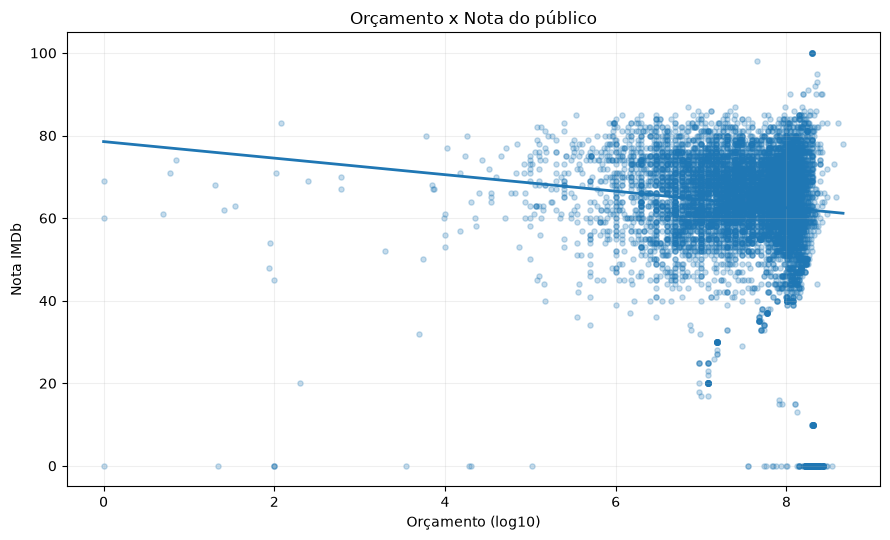

In [24]:

# Gráfico principal: orçamento x nota
dados_graf = df[["log_budget", "score"]].dropna()

plt.figure(figsize=(9, 5.5))
plt.scatter(dados_graf["log_budget"], dados_graf["score"], alpha=0.25, s=14)

coef = np.polyfit(dados_graf["log_budget"], dados_graf["score"], 1)
x = np.linspace(dados_graf["log_budget"].min(), dados_graf["log_budget"].max(), 100)
plt.plot(x, np.polyval(coef, x), linewidth=2)

plt.xlabel("Orçamento (log10)")
plt.ylabel("Nota IMDb")
plt.title("Orçamento x Nota do público")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


#### Conclusão — Pergunta 9

Os dados **não confirmam** a hipótese de que um orçamento maior produz uma nota maior.

A correlação encontrada é negativa e fraca/moderada em magnitude. Além disso, os filmes com nota ≥ 80 apresentam orçamento mediano inferior ao dos demais filmes.

Isso não significa que orçamento seja irrelevante. O orçamento pode ser necessário para produção, elenco, efeitos, distribuição e marketing. O ponto é que **o orçamento, isoladamente, não explica a aceitação do público**.

#### 10. Qualidade e confiabilidade dos dados

In [25]:

# Valores faltantes
print("Valores ausentes por coluna:")
display(df.isna().sum().sort_values(ascending=False).to_frame("nulos"))

# Faixas suspeitas
print("\nNotas fora do intervalo esperado [0, 100]:")
display(df.loc[(df["score"] < 0) | (df["score"] > 100), ["names", "score"]])

print("\nQuantidade de notas exatamente 100:")
print((df["score"] == 100).sum())

print("\nOrçamento <= 0:")
print((df["budget_x"] <= 0).sum())

print("\nReceita <= 0:")
print((df["revenue"] <= 0).sum())

print("\nLinhas duplicadas completas:")
print(df.duplicated().sum())


Valores ausentes por coluna:


,nulos
genre,85
log_revenue,73
crew,56
names,0
date_x,0
score,0
orig_title,0
status,0
orig_lang,0
overview,0



Notas fora do intervalo esperado [0, 100]:


,names,score



Quantidade de notas exatamente 100:
9

Orçamento <= 0:
0

Receita <= 0:
73

Linhas duplicadas completas:
0


In [26]:

# Diagnóstico de repetição de pares financeiros
pares_financeiros = (
    df.groupby(["budget_x", "revenue"], dropna=False)
      .size()
      .reset_index(name="qtd_filmes")
      .query("qtd_filmes > 1")
      .sort_values("qtd_filmes", ascending=False)
)

print(f"Pares orçamento/receita repetidos: {len(pares_financeiros):,}")
print(f"Filmes pertencentes a pares repetidos: "
      f"{df.merge(pares_financeiros[['budget_x','revenue']],
                 on=['budget_x','revenue'], how='inner').shape[0]:,}")

display(pares_financeiros.head(15))


Pares orçamento/receita repetidos: 754
Filmes pertencentes a pares repetidos: 2,319


,budget_x,revenue,qtd_filmes
8254,"167,540,000.00","175,269,998.80",36
2225,"12,001,040.00","38,139,010.00",26
8313,"174,600,000.00","175,269,998.80",24
2568,"15,541,000.00","38,139,010.00",23
8505,"201,940,000.00","38,157,314.00",20
8383,"181,600,000.00","175,269,998.80",18
5753,"79,500,000.00","708,023,892.40",14
8598,"264,940,000.00","175,269,998.80",13
6509,"100,000,000.00","369,861,963.80",11
6335,"95,600,000.00","305,560,367.80",11


#### Conclusão sobre qualidade dos dados

Foram encontrados sinais que recomendam cautela, especialmente nas variáveis financeiras:

- pares de orçamento/receita repetidos em muitos filmes;
- valores financeiros que merecem validação;
- notas extremas que precisam ser investigadas;
- ausência de variáveis importantes para explicar profissionais, franquias e marketing.

Por isso, as análises de receita e orçamento devem ser apresentadas como **exploratórias**, e não como base única para uma decisão real de investimento.

# Conclusão executiva

### O que os dados sugerem?

**1. Aceitação do público e retorno financeiro são dimensões diferentes.**  
A receita apresenta relação fraca com a nota.

**2. Mais orçamento não significa maior nota.**  
O orçamento não apresenta relação positiva com a avaliação do público.

**3. O gênero apresenta diferenças de nota média.**  
Entretanto, gênero sozinho não explica o sucesso.

**4. Filmes muito bem avaliados não dependem necessariamente de grandes orçamentos.**  
A mediana de orçamento dos filmes com nota ≥ 80 é menor que a dos demais filmes.

**5. O dataset não é suficiente para explicar o papel das pessoas por trás dos filmes.**  
Faltam informações estruturadas sobre direção, produção, roteiro e estúdios.

**6. Franquias também não podem ser analisadas de forma completa.**  
Falta uma identificação estruturada das séries/continuações.

**7. Há limitações de qualidade nos dados financeiros.**  
Antes de usar os resultados para investimento, orçamento e receita deveriam ser validados com uma fonte confiável.

### Recomendação de negócio

Em vez de procurar uma única variável que "garanta" sucesso, a próxima análise deveria construir um **modelo de sucesso multidimensional**, combinando:

`nota do público + receita + orçamento + gênero + diretor + produtor + estúdio + franquia + marketing + distribuição`.

O objetivo seria identificar perfis de filmes que apresentam simultaneamente **boa aceitação e bom retorno**, além dos casos em que existe **alto retorno com baixa reputação** ou **alta reputação com baixo retorno**.
